## 0. Setup

In [1]:
import sys
import os
from pathlib import Path
# Add project root to path (works for both local and Colab)
project_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
# !pip install uv

In [3]:
# !cd /sae-monosemantic && uv pip install --system -e .

In [4]:
# !apt-get update && apt-get install -y rsync

In [5]:
import torch
from itertools import islice
from torch.utils.data import Dataset, DataLoader
from src.models.spare_autoencoder import SparseAutoEncoder
from src.training.dataset_creator import ChunkIterableGenerator, split_files
from src.training.losses import compute_loss
from src.training.trainer import SAETrainer
from typing import Optional, Callable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wandb


In [6]:
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA build:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
Torch CUDA build: 12.8
GPU: NVIDIA A100-SXM4-80GB


In [7]:
# Hyperparameters:
hyperparameters = {
    "num_epochs": 20,
    "expansion_factor": 8,
    "batch_size": 32,
    "num_workers": 0,
    "lr": 1e-4,
    "log_frequency": 5000
}


In [8]:
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="adityaiyer-m-self",
    # Set the wandb project where this run will be logged.
    project="sae-for-monosemanticity",
    # Track hyperparameters and run metadata.
    config=hyperparameters,
)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: adityaiyer-m (adityaiyer-m-self) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [9]:
MODEL_SAVE_PATH = project_root / f'model_weights_{hyperparameters["expansion_factor"]}x.pth'

## 1. Load data

In [10]:
activation_chunk_dir = str(project_root / 'data' / 'gpt2_activation_chunks')
train_files, val_files, test_files = split_files(activation_chunk_dir)

print(f"Number of Training Files: {len(train_files)}")
print(f"Number of Validation Files: {len(val_files)}")
print(f"Number of Testing Files: {len(test_files)}")

Number of Training Files: 40
Number of Validation Files: 5
Number of Testing Files: 5


In [11]:
train_chunk_generator = ChunkIterableGenerator(train_files)
val_chunk_generator = ChunkIterableGenerator(val_files)
test_chunk_generator = ChunkIterableGenerator(test_files)

In [12]:
training_dataloader = torch.utils.data.DataLoader(train_chunk_generator, batch_size=hyperparameters["batch_size"], num_workers=hyperparameters["num_workers"])
val_dataloader = torch.utils.data.DataLoader(val_chunk_generator, batch_size=hyperparameters["batch_size"], num_workers=hyperparameters["num_workers"])
test_dataloader = torch.utils.data.DataLoader(test_chunk_generator, batch_size=hyperparameters["batch_size"], num_workers=hyperparameters["num_workers"])


## 2. Define Model

In [13]:
model = SparseAutoEncoder(d_model=768, expansion_factor=hyperparameters["expansion_factor"])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

## 3. Training

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=hyperparameters["lr"])
loss_fn = compute_loss

In [15]:
TRAIN_MODEL = True  # Set to False to skip training and load saved weights

trainer = SAETrainer(
    model=model,
    dataloader=training_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device
)

if TRAIN_MODEL:
    trainer.train(
        num_epochs=hyperparameters["num_epochs"],
        log_every=hyperparameters["log_frequency"],
    )
else:
    if not os.path.exists(MODEL_SAVE_PATH):
        raise FileNotFoundError(
            f"No saved weights found at {MODEL_SAVE_PATH}. "
            "Set TRAIN_MODEL = True to train from scratch."
        )
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    print(f"Loaded model weights from {MODEL_SAVE_PATH}. Skipping training.")

Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_0.pt
activations and token_ids extracted
Epoch 0, Batch 0, Loss: 569.576904
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_0.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_2.pt
activations and token_ids extracted
Epoch 0, Batch 5000, Loss: 0.653589
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_2.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_3.pt
activations and token_ids extracted
Epoch 0, Batch 10000, Loss: 0.152421
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_3.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_4.pt
activations and token_ids extracted
Epoch 0, Batch 15000, Loss: 0.195085
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_4.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_9.pt
activations and to

In [16]:
run.log({
    "training_loss_curve": wandb.plot.line_series(
        xs=list(range(len(trainer.training_losses))),
        ys=[trainer.training_losses],
        keys=["Training Loss"],
        title="Training Loss",
        xname="Step"
    )
})

## 4. Visualize Training Loss

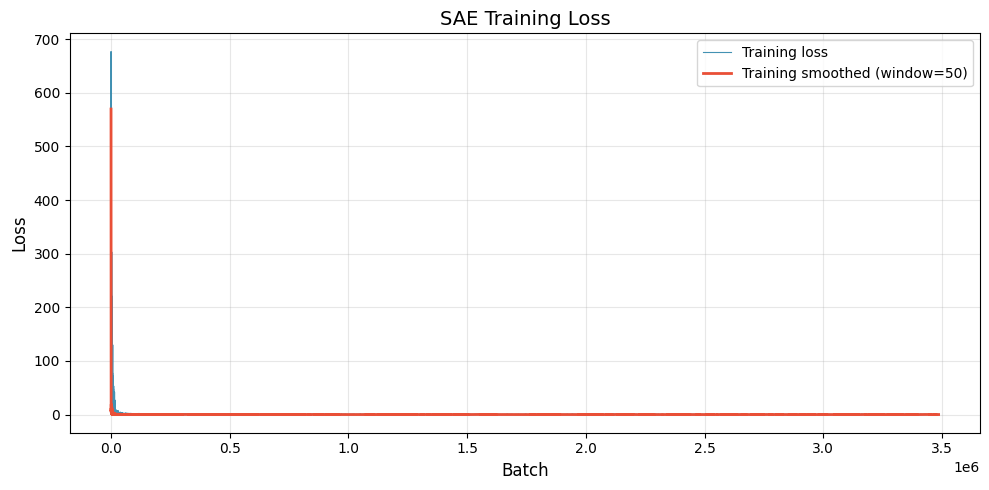

In [17]:
# Plot training loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trainer.training_losses, color='#2e86ab', linewidth=0.8, alpha=0.9, label='Training loss')

# Optionally smooth the training curve for readability (rolling mean)
if len(trainer.training_losses) > 50:
    window = min(50, len(trainer.training_losses) // 10)
    smoothed = pd.Series(trainer.training_losses).rolling(window=window, min_periods=1).mean()
    ax.plot(smoothed.values, color='#e94f37', linewidth=2, label=f'Training smoothed (window={window})')

ax.set_xlabel('Batch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('SAE Training Loss', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# intermediate save
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f" model weights saved to {MODEL_SAVE_PATH}")

 model weights saved to /sae-monosemantic/model_weights_8x.pth


## 5. Validation

In [19]:
validation_loss, validation_num_batches =  trainer.evaluate(val_dataloader)

Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_5.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_5.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_6.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_6.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_8.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_8.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_14.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_14.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_34.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_34.pt


In [20]:
run.log({
    "validation_loss_curve": wandb.plot.line_series(
        xs=list(range(len(validation_loss))),
        ys=[validation_loss],
        keys=["Validation Loss"],
        title="Validation Loss",
        xname="Step"
    )
})

## 6. Visualize Validation Loss

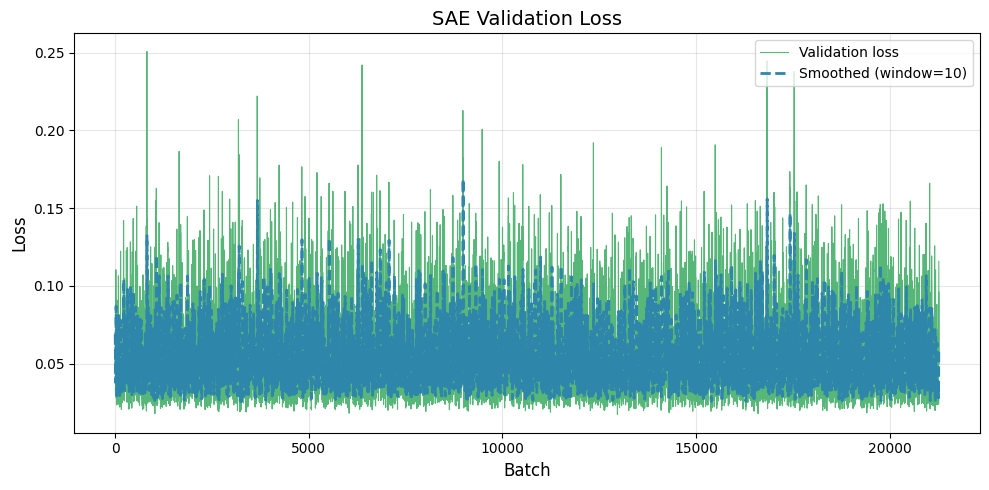

In [21]:
# Plot validation loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(validation_loss, color='#44af69', linewidth=0.8, alpha=0.9, label='Validation loss')

# Optionally smooth the curve for readability (rolling mean)
if len(validation_loss) > 10:
    window = min(10, len(validation_loss) // 5)
    smoothed = pd.Series(validation_loss).rolling(window=window, min_periods=1).mean()
    ax.plot(smoothed.values, color='#2e86ab', linewidth=2, linestyle='--', label=f'Smoothed (window={window})')

ax.set_xlabel('Batch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('SAE Validation Loss', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Save Model

In [22]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f" model weights saved to {MODEL_SAVE_PATH}")

 model weights saved to /sae-monosemantic/model_weights_8x.pth


In [23]:
artifact = wandb.Artifact(name="sae-weights", type="model")
artifact.add_file(str(MODEL_SAVE_PATH))
run.log_artifact(artifact)
print(f"Logged artifact 'sae-weights' to wandb")

Logged artifact 'sae-weights' to wandb


## 8. Test Model

In [24]:
test_loss, test_num_batches = trainer.evaluate(test_dataloader)

Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_1.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_1.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_7.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_7.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_15.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_15.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_17.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_17.pt
Loading chunk file: /sae-monosemantic/data/gpt2_activation_chunks/chunk_40.pt
activations and token_ids extracted
Finished processing /sae-monosemantic/data/gpt2_activation_chunks/chunk_40.pt


In [25]:
run.log({
    "test_loss_curve": wandb.plot.line_series(
        xs=list(range(len(test_loss))),
        ys=[test_loss],
        keys=["Test Loss"],
        title="Test Loss",
        xname="Step"
    )
})

## 9. Visualize Test Loss

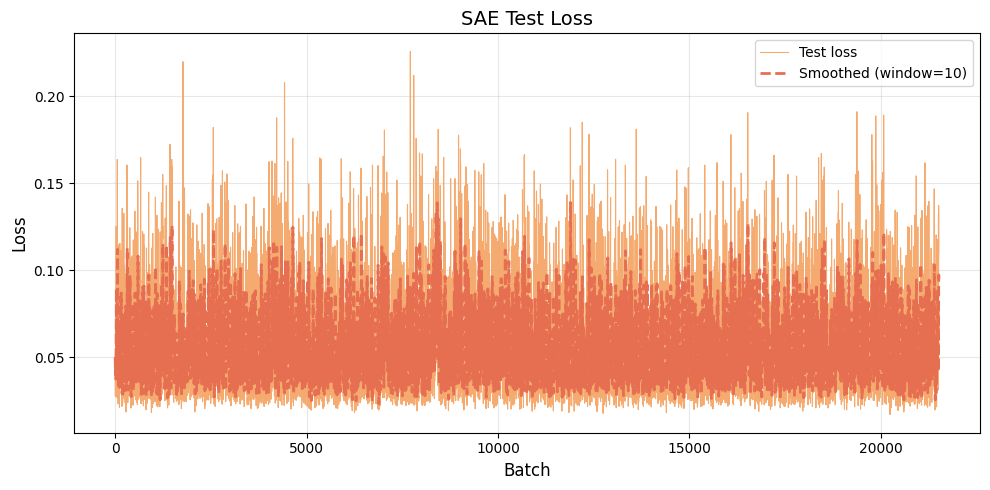

In [26]:
# Plot test loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_loss, color='#f4a261', linewidth=0.8, alpha=0.9, label='Test loss')

# Optionally smooth the curve for readability (rolling mean)
if len(test_loss) > 10:
    window = min(10, len(test_loss) // 5)
    smoothed = pd.Series(test_loss).rolling(window=window, min_periods=1).mean()
    ax.plot(smoothed.values, color='#e76f51', linewidth=2, linestyle='--', label=f'Smoothed (window={window})')

ax.set_xlabel('Batch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('SAE Test Loss', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Compute Loss Statistics

In [27]:
def compute_loss_stats(losses, split_name):
    arr = np.asarray(losses, dtype=float)
    if arr.size == 0:
        return {
            "split": split_name,
            "num_batches": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "median": np.nan,
        }

    return {
        "split": split_name,
        "num_batches": int(arr.size),
        "mean": float(arr.mean()),
        "std": float(arr.std()),
        "min": float(arr.min()),
        "max": float(arr.max()),
        "median": float(np.median(arr)),
    }

In [28]:
stats_df = (
    pd.DataFrame([
        compute_loss_stats(trainer.training_losses, "train"),
        compute_loss_stats(validation_loss, "val"),
        compute_loss_stats(test_loss, "test"),
    ])
    .set_index("split")
)

# Format without .style (no jinja2)
stats_df_display = stats_df.copy()
stats_df_display["num_batches"] = stats_df_display["num_batches"].astype("int64")
for c in ["mean", "std", "min", "max", "median"]:
    stats_df_display[c] = stats_df_display[c].round(6)

display(stats_df_display)

,num_batches,mean,std,min,max,median
split,,,,,,
train,3486240,0.078653,0.881179,0.009400,676.872864,0.054635
val,21273,0.054559,0.026951,0.017306,0.250775,0.046767
test,21516,0.055292,0.027401,0.017139,0.225568,0.047165


In [29]:
wandb.log({
    "train_loss_mean": stats_df.loc["train", "mean"],
    "train_loss_std": stats_df.loc["train", "std"],
    "val_loss_mean": stats_df.loc["val", "mean"],
    "val_loss_std": stats_df.loc["val", "std"],
    "test_loss_mean": stats_df.loc["test", "mean"],
    "test_loss_std": stats_df.loc["test", "std"],
})


In [30]:
wandb.finish()

test_loss_mean,▁
test_loss_std,▁
train_loss_mean,▁
train_loss_std,▁
val_loss_mean,▁
val_loss_std,▁
test_loss_mean,0.05529
test_loss_std,0.0274
train_loss_mean,0.07865
train_loss_std,0.88118
val_loss_mean,0.05456
